In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("tensorflow:", tf.__version__)

tensorflow: 2.21.0


In [2]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "Dataset" / "rockpaperscissors" / "train"
CLASSES = ["paper", "rock", "scissors"]  # alphabetical, matches class indices below

for cls in CLASSES:
    print(f"{cls:>8}: {len(list((DATA_DIR / cls).glob('*.png')))} images")

   paper: 712 images
    rock: 726 images
scissors: 750 images


In [3]:
IMG_SIZE = (224, 224)  # MobileNetV2's native input size
BATCH_SIZE = 32
SEED = 42
SPLIT = 0.4

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),  # lighting varies wildly in the wild
    validation_split=SPLIT,
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=SPLIT,
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED,
)

val_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False,
)

print()
print("class indices:", train_generator.class_indices)

Found 1314 images belonging to 3 classes.


Found 874 images belonging to 3 classes.



class indices: {'paper': 0, 'rock': 1, 'scissors': 2}


In [4]:
overlap = set(train_generator.filenames) & set(val_generator.filenames)
print(f"images shared between train and val: {len(overlap)}")

images shared between train and val: 0


In [5]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  # freeze for the head-training phase

model = Sequential(
    [
        Input(shape=IMG_SIZE + (3,)),
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.3),
        Dense(3, activation="softmax"),
    ]
)

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

model.summary()

      0/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  32768/9406464 ━━━━━━━━━━━━━━━━━━━━ 16s 2us/step

  49152/9406464 ━━━━━━━━━━━━━━━━━━━━ 46s 5us/step

  81920/9406464 ━━━━━━━━━━━━━━━━━━━━ 52s 6us/step

 114688/9406464 ━━━━━━━━━━━━━━━━━━━━ 42s 5us/step

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
head_history = model.fit(
    train_generator,
    epochs=6,
    validation_data=val_generator,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True)],
)

Epoch 1/6


 1/42 ━━━━━━━━━━━━━━━━━━━━ 5:20 8s/step - accuracy: 0.1875 - loss: 2.1438

 2/42 ━━━━━━━━━━━━━━━━━━━━ 17s 439ms/step - accuracy: 0.2656 - loss: 1.8975

 3/42 ━━━━━━━━━━━━━━━━━━━━ 18s 466ms/step - accuracy: 0.2188 - loss: 1.8143

 4/42 ━━━━━━━━━━━━━━━━━━━━ 17s 471ms/step - accuracy: 0.2266 - loss: 1.7683

...

39/42 ━━━━━━━━━━━━━━━━━━━━ 1s 475ms/step - accuracy: 0.9819 - loss: 0.0657

40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.9816 - loss: 0.0660

41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9821 - loss: 0.0659

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.9825 - loss: 0.0649

42/42 ━━━━━━━━━━━━━━━━━━━━ 29s 698ms/step - accuracy: 0.9825 - loss: 0.0649 - val_accuracy: 0.9943 - val_loss: 0.0379


In [7]:
# Phase 2: unfreeze the top third of the base model for fine-tuning
base_model.trainable = True
fine_tune_from = int(len(base_model.layers) * 2 / 3)
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-5),  # tiny: protect pretrained features
    metrics=["accuracy"],
)
print(f"fine-tuning layers {fine_tune_from}..{len(base_model.layers)} of {len(base_model.layers)}")

fine-tuning layers 102..154 of 154


In [8]:
fine_history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=3, restore_best_weights=True)],
)

Epoch 1/10


 1/42 ━━━━━━━━━━━━━━━━━━━━ 11:50 17s/step - accuracy: 0.6250 - loss: 0.8378

 2/42 ━━━━━━━━━━━━━━━━━━━━ 32s 805ms/step - accuracy: 0.6875 - loss: 0.7143

 3/42 ━━━━━━━━━━━━━━━━━━━━ 29s 761ms/step - accuracy: 0.7083 - loss: 0.7163

 4/42 ━━━━━━━━━━━━━━━━━━━━ 28s 748ms/step - accuracy: 0.6719 - loss: 0.8066

...

39/42 ━━━━━━━━━━━━━━━━━━━━ 2s 703ms/step - accuracy: 0.9852 - loss: 0.0674

40/42 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step - accuracy: 0.9856 - loss: 0.0666

41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.9860 - loss: 0.0655

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.9855 - loss: 0.0652

42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 927ms/step - accuracy: 0.9855 - loss: 0.0652 - val_accuracy: 0.9794 - val_loss: 0.0610


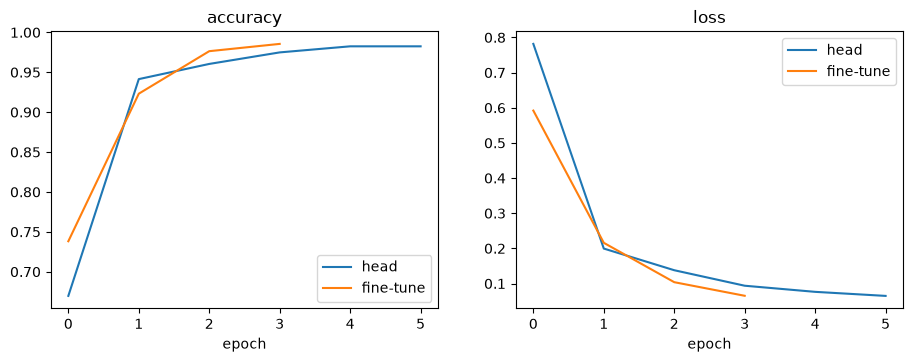

In [9]:
def plot_history(histories, titles):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for ax, key, title in zip(axes, titles, ("accuracy", "loss")):
        for hist, label in histories:
            ax.plot(hist.history[key], label=label)
        ax.set_title(title)
        ax.set_xlabel("epoch")
        ax.legend()
    plt.show()

plot_history(
    [(head_history, "head"), (fine_history, "fine-tune")],
    ["accuracy", "loss"],
)

In [10]:
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"validation accuracy: {val_acc:.1%}")
print(f"validation loss:     {val_loss:.3f}")

validation accuracy: 98.6%
validation loss:     0.049


In [11]:
rng = np.random.default_rng(7)
n_per_class = 25
print('sample of', n_per_class, 'images per class, preprocessed like app.py:')
print()

for cls in CLASSES:
    files = sorted((DATA_DIR / cls).glob('*.png'))
    picked = rng.choice(len(files), size=n_per_class, replace=False)
    correct = 0
    for i in picked:
        img = tf.keras.utils.load_img(files[i], target_size=IMG_SIZE)
        x = np.asarray(img, dtype=np.float32)
        x = preprocess_input(x)  # [-1, 1], same as app.py
        probs = model.predict(np.expand_dims(x, 0), verbose=0)[0]
        correct += CLASSES[int(np.argmax(probs))] == cls
    print(f'{cls:>8}: {correct}/{n_per_class} called correctly')

sample of 25 images per class, preprocessed like app.py:



   paper: 23/25 called correctly


    rock: 25/25 called correctly


scissors: 25/25 called correctly


In [12]:
model.save("model.h5")